In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

In [17]:
ml_df = pd.read_parquet(
    "../data/processed/cybersecurity_ml_ready.parquet"
)

ml_df.head()

,protocol,packet_length,traffic_type,anomaly_scores,severity_level,network_segment,mexico_state,attack_type
0,0,503,2,28.67,1,0,3,2
1,0,1174,2,51.50,1,1,7,2
2,2,306,2,87.42,1,2,9,0
3,2,385,2,15.79,2,1,9,2
4,1,1462,0,0.52,1,2,11,0


In [18]:
X = ml_df.drop("attack_type", axis=1)
y = ml_df["attack_type"]

print(X.shape)
print(y.shape)

(40000, 7)
(40000,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(32000, 7)
(8000, 7)


In [20]:
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [21]:
y_pred_xgb = xgb_model.predict(X_test)

print(y_pred_xgb[:10])

[0 2 1 1 2 1 2 2 2 0]


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

precision, recall, f1, _ = (
    precision_recall_fscore_support(
        y_test,
        y_pred_xgb,
        average="weighted"
    )
)

In [23]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.323125


In [24]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.32      0.34      0.33      2636
           1       0.33      0.30      0.32      2721
           2       0.32      0.33      0.33      2643

    accuracy                           0.32      8000
   macro avg       0.32      0.32      0.32      8000
weighted avg       0.32      0.32      0.32      8000



In [25]:
xgb_cm = confusion_matrix(y_test, y_pred_xgb)

print(xgb_cm)

[[890 848 898]
 [979 826 916]
 [956 818 869]]


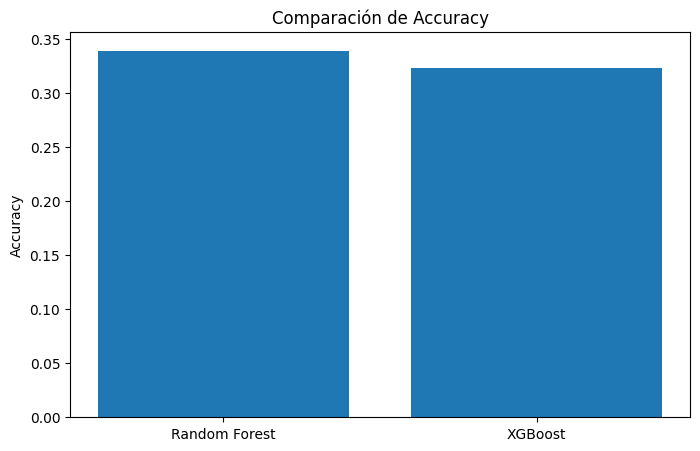

In [26]:
models = ["Random Forest", "XGBoost"]
accuracies = [0.3394, xgb_accuracy]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Comparación de Accuracy")
plt.ylabel("Accuracy")

plt.show()

In [27]:
xgb_importance = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df

,feature,importance
1,packet_length,0.150967
6,mexico_state,0.148240
3,anomaly_scores,0.147037
2,traffic_type,0.140180
0,protocol,0.138838
4,severity_level,0.138333
5,network_segment,0.136407


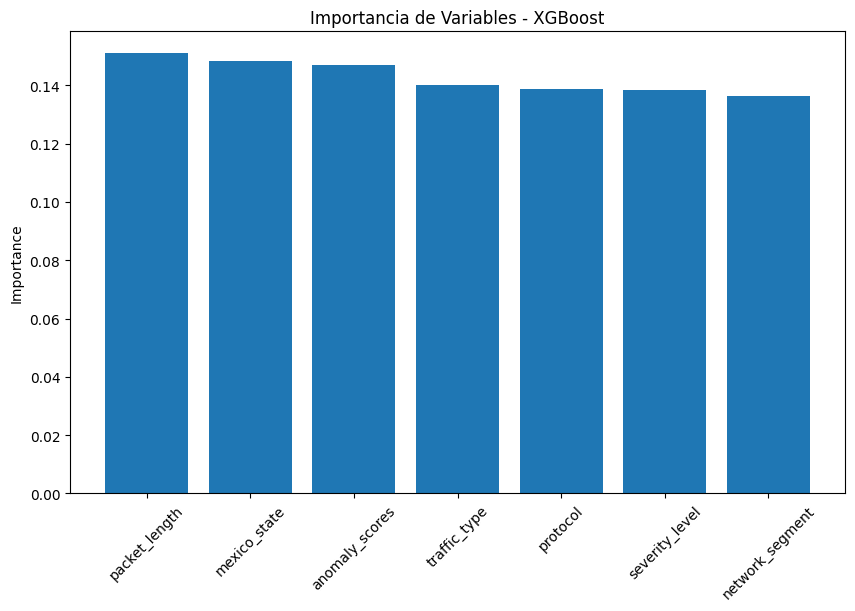

In [28]:
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)

plt.xticks(rotation=45)

plt.title("Importancia de Variables - XGBoost")
plt.ylabel("Importance")

plt.show()

In [29]:
import seaborn as sns

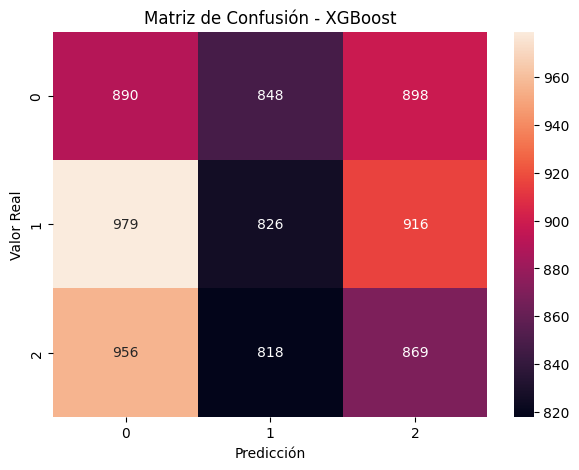

In [30]:
plt.figure(figsize=(7,5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión - XGBoost")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [31]:
import json
import os

os.makedirs(
    "../data/metrics",
    exist_ok=True
)

xgb_metrics = {
    "model": "XGBoost",
    "accuracy": float(xgb_accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1)
}

with open(
    "../data/metrics/xgboost_metrics.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        xgb_metrics,
        f,
        indent=4
    )

print("XGBoost metrics exported")

XGBoost metrics exported
